# 5. Negative Passage 성능 실험

본 노트북은 다양한 **Negative Passage 전략**이 MRC 모델 성능에 미치는 영향을 실험합니다.

**실험 목표:**
- Random Negative vs Hard Negative 전략 비교
- Negative Passage 개수에 따른 성능 변화 분석
- 최적의 Negative Passage 전략 도출


## 5.1. 환경 설정 및 라이브러리 Import


In [1]:
# 가상환경(.venv) 경로 자동 추가import sysfrom pathlib import Path# 프로젝트 루트 찾기project_root = Path().resolve().parent.parentvenv_path = project_root / ".venv"if venv_path.exists():    # Python 버전에 맞는 site-packages 경로 찾기    python_version = f"{sys.version_info.major}.{sys.version_info.minor}"    venv_site_packages = venv_path / "lib" / f"python{python_version}" / "site-packages"        # site-packages가 없으면 다른 가능한 경로 시도    if not venv_site_packages.exists():        lib_dir = venv_path / "lib"        if lib_dir.exists():            for py_dir in lib_dir.iterdir():                if py_dir.is_dir() and py_dir.name.startswith("python"):                    site_packages = py_dir / "site-packages"                    if site_packages.exists():                        venv_site_packages = site_packages                        break        if venv_site_packages.exists():        venv_path_str = str(venv_site_packages)        if venv_path_str not in sys.path:            sys.path.insert(0, venv_path_str)        print(f"✅ 가상환경(.venv) 경로 추가됨: {venv_site_packages}")    else:        print(f"⚠️ 가상환경(.venv)이 존재하지만 site-packages를 찾을 수 없습니다")else:    print(f"ℹ️ 가상환경(.venv)이 없습니다. 시스템 Python을 사용합니다")
# 노트북 독립 실행을 위한 환경 설정import sysfrom pathlib import Path# 프로젝트 루트를 sys.path에 추가project_root = Path().resolve().parent.parentif str(project_root) not in sys.path:    sys.path.insert(0, str(project_root))# 공통 유틸리티 importtry:    from notebooks.utils import setup_notebook_environment, load_dataset_safely, load_json_safely        # 환경 설정    paths = setup_notebook_environment()    print(f"✅ 프로젝트 루트: {paths['project_root']}")    print(f"✅ 데이터 디렉토리: {paths['data_dir']}")except ImportError as e:    print(f"⚠️ 유틸리티 import 실패: {e}")    paths = {        'project_root': project_root,        'data_dir': project_root / 'data',        'notebook_dir': project_root / 'notebooks'    }
# accelerate 버전 호환성 문제 해결 (transformers와 accelerate 버전 불일치 시 실행)
# 실행 후 커널을 재시작하세요.
%pip install --upgrade accelerate


Note: you may need to restart the kernel to use updated packages.


In [2]:
# accelerate 버전 호환성 문제 해결 (필요시 실행)
# !pip install --upgrade accelerate

# OpenMP 충돌 방지 설정 (Windows 환경)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

# 필요한 라이브러리 import
import sys
import json
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datasets import Dataset, DatasetDict, load_from_disk
from typing import List, Dict, Tuple, Optional
from tqdm.auto import tqdm
import re
import math
import evaluate
from dataclasses import dataclass, field

# Transformers
from transformers import (
    AutoConfig,
    AutoModelForQuestionAnswering,
    AutoTokenizer,
    DataCollatorWithPadding,
    EvalPrediction,
    TrainingArguments,
    Trainer,
    set_seed,
)

# 프로젝트 루트 경로 설정
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))

# src 모듈 import
from src.config import DataTrainingArguments, ModelArguments
from src.training.trainer_qa import QuestionAnsweringTrainer
from src.utils import postprocess_qa_predictions

# 시각화 설정
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")

# 재현성을 위한 시드 설정
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"프로젝트 루트: {project_root}")
print(f"사용 디바이스: {device}")
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


프로젝트 루트: D:\Repos\pro-nlp-mrc-nlp-01
사용 디바이스: cuda
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 2070


In [3]:
# 한글 폰트 설정
import matplotlib
import platform

def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        font_name = 'Malgun Gothic'
    elif system == 'Darwin':  # Mac
        font_name = 'AppleGothic'
    else:  # Linux
        font_name = 'NanumGothic'
    matplotlib.rc('font', family=font_name)
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()


## 5.2. 데이터 로드


In [4]:
# 데이터 경로 설정
data_root = project_root / "data"
train_dataset_path = data_root / "train_dataset"
wikipedia_documents_path = data_root / "wikipedia_documents.json"

# 데이터 로드
print("데이터셋 로드 중...")
train_datasets = load_from_disk(str(train_dataset_path))

with open(wikipedia_documents_path, 'r', encoding='utf-8') as f:
    wiki_documents = json.load(f)

print(f"Train dataset: {len(train_datasets['train'])} samples")
print(f"Validation dataset: {len(train_datasets['validation'])} samples")
print(f"Wikipedia documents: {len(wiki_documents)} documents")
print(f"\n데이터셋 컬럼: {train_datasets['train'].column_names}")


데이터셋 로드 중...
Train dataset: 3952 samples
Validation dataset: 240 samples
Wikipedia documents: 60613 documents

데이터셋 컬럼: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__']


In [5]:
# Wikipedia 문서를 리스트로 변환 (중복 제거)
context_texts = [v["text"] for v in wiki_documents.values()]
all_contexts = list(dict.fromkeys(context_texts))  # 중복 제거
print(f"중복 제거 후 Wikipedia 문서 개수: {len(all_contexts)}")


중복 제거 후 Wikipedia 문서 개수: 56737


## 5.3. BM25 Retriever 구현


In [6]:
def tokenize(text: str) -> List[str]:
    """간단한 토크나이저 - 공백 기준 분리"""
    return text.lower().split()

class BM25Retriever:
    """BM25 알고리즘을 사용한 Retrieval 시스템"""
    
    def __init__(self, contexts: List[str], k1: float = 1.5, b: float = 0.75):
        """
        Args:
            contexts: 검색 대상 문서 리스트
            k1: term frequency saturation parameter (기본값: 1.5)
            b: length normalization parameter (기본값: 0.75)
        """
        self.contexts = contexts
        self.k1 = k1
        self.b = b
        
        # 문서 토큰화 및 통계 계산
        print("BM25 인덱스 구축 중...")
        self.tokenized_docs = [tokenize(doc) for doc in tqdm(contexts, desc="Tokenizing documents")]
        
        # 문서별 단어 빈도 계산
        self.doc_freqs = []
        self.doc_lengths = []
        
        for doc_tokens in self.tokenized_docs:
            doc_freq = Counter(doc_tokens)
            self.doc_freqs.append(doc_freq)
            self.doc_lengths.append(len(doc_tokens))
        
        # 전체 문서 평균 길이
        self.avg_doc_length = sum(self.doc_lengths) / len(self.doc_lengths) if self.doc_lengths else 0
        
        # 전체 문서에서의 단어 빈도 (IDF 계산용)
        self.doc_freq = Counter()
        for doc_freq in self.doc_freqs:
            self.doc_freq.update(doc_freq.keys())
        
        self.num_docs = len(self.contexts)
        print(f"BM25 인덱스 구축 완료: {self.num_docs}개 문서")
    
    def get_idf(self, term: str) -> float:
        """Inverse Document Frequency 계산"""
        if term not in self.doc_freq:
            return 0.0
        return math.log((self.num_docs - self.doc_freq[term] + 0.5) / (self.doc_freq[term] + 0.5))
    
    def get_score(self, query_tokens: List[str], doc_idx: int) -> float:
        """BM25 점수 계산"""
        score = 0.0
        doc_freq = self.doc_freqs[doc_idx]
        doc_length = self.doc_lengths[doc_idx]
        
        for term in query_tokens:
            if term in doc_freq:
                tf = doc_freq[term]
                idf = self.get_idf(term)
                numerator = idf * tf * (self.k1 + 1)
                denominator = tf + self.k1 * (1 - self.b + self.b * (doc_length / self.avg_doc_length))
                score += numerator / denominator
        
        return score
    
    def get_relevant_doc(self, query: str, k: int = 10) -> Tuple[List[float], List[int]]:
        """질문에 대해 상위 k개 문서 검색"""
        query_tokens = tokenize(query)
        
        scores = []
        for doc_idx in range(self.num_docs):
            score = self.get_score(query_tokens, doc_idx)
            scores.append((score, doc_idx))
        
        scores.sort(reverse=True, key=lambda x: x[0])
        top_k = scores[:k]
        doc_scores = [score for score, _ in top_k]
        doc_indices = [idx for _, idx in top_k]
        
        return doc_scores, doc_indices

# BM25 Retriever 초기화
print("\nBM25 Retriever 초기화 중...")
bm25_retriever = BM25Retriever(all_contexts, k1=1.5, b=0.75)
print("BM25 Retriever 준비 완료")



BM25 Retriever 초기화 중...
BM25 인덱스 구축 중...


Tokenizing documents: 100%|██████████| 56737/56737 [00:02<00:00, 28145.29it/s]


BM25 인덱스 구축 완료: 56737개 문서
BM25 Retriever 준비 완료


## 5.4. Negative Passage 샘플링 전략


In [7]:
def check_answer_in_context(answer_text: str, context: str) -> bool:
    """Context에 정답이 포함되어 있는지 확인"""
    if not answer_text or not context:
        return False
    answer_normalized = re.sub(r'\s+', ' ', answer_text.strip().lower())
    context_normalized = re.sub(r'\s+', ' ', context.strip().lower())
    return answer_normalized in context_normalized


class NegativePassageSampler:
    """다양한 Negative Passage 샘플링 전략을 제공하는 클래스"""
    
    def __init__(self, all_contexts: List[str], bm25_retriever: BM25Retriever):
        self.all_contexts = all_contexts
        self.bm25_retriever = bm25_retriever
        self.context_set = set(all_contexts)
    
    def sample_random_negatives(
        self,
        positive_context: str,
        answer_text: str,
        num_negatives: int = 1
    ) -> List[str]:
        """
        랜덤 Negative 샘플링
        - 정답이 포함되지 않은 임의의 문서 선택
        """
        negatives = []
        attempts = 0
        max_attempts = num_negatives * 10
        
        while len(negatives) < num_negatives and attempts < max_attempts:
            idx = random.randint(0, len(self.all_contexts) - 1)
            candidate = self.all_contexts[idx]
            
            # 조건: positive가 아니고, 정답이 포함되지 않은 문서
            if candidate != positive_context and not check_answer_in_context(answer_text, candidate):
                if candidate not in negatives:
                    negatives.append(candidate)
            attempts += 1
        
        return negatives
    
    def sample_bm25_hard_negatives(
        self,
        question: str,
        positive_context: str,
        answer_text: str,
        num_negatives: int = 1,
        top_k: int = 50
    ) -> List[str]:
        """
        BM25 Hard Negative 샘플링
        - BM25 스코어가 높지만 정답이 포함되지 않은 문서 선택
        """
        _, doc_indices = self.bm25_retriever.get_relevant_doc(question, k=top_k)
        
        negatives = []
        for idx in doc_indices:
            candidate = self.all_contexts[idx]
            
            # 조건: positive가 아니고, 정답이 포함되지 않은 문서
            if candidate != positive_context and not check_answer_in_context(answer_text, candidate):
                negatives.append(candidate)
                if len(negatives) >= num_negatives:
                    break
        
        return negatives
    
    def sample_mixed_negatives(
        self,
        question: str,
        positive_context: str,
        answer_text: str,
        num_hard: int = 1,
        num_random: int = 1
    ) -> List[str]:
        """
        혼합 Negative 샘플링 (Hard + Random)
        """
        hard_negatives = self.sample_bm25_hard_negatives(
            question, positive_context, answer_text, num_hard
        )
        random_negatives = self.sample_random_negatives(
            positive_context, answer_text, num_random
        )
        
        # 중복 제거
        all_negatives = hard_negatives + [n for n in random_negatives if n not in hard_negatives]
        return all_negatives[:num_hard + num_random]


# Negative Sampler 초기화
negative_sampler = NegativePassageSampler(all_contexts, bm25_retriever)
print("Negative Passage Sampler 준비 완료")


Negative Passage Sampler 준비 완료


## 5.5. 학습 데이터 생성 함수


In [8]:
def create_augmented_dataset(
    original_dataset,
    negative_sampler: NegativePassageSampler,
    strategy: str = 'none',  # 'none', 'random', 'hard', 'mixed'
    num_negatives: int = 1,
    include_negative_examples: bool = True
) -> Dataset:
    """
    Negative Passage를 포함한 학습 데이터셋 생성
    
    Args:
        original_dataset: 원본 데이터셋
        negative_sampler: Negative 샘플러
        strategy: 샘플링 전략 ('none', 'random', 'hard', 'mixed')
        num_negatives: Negative 개수
        include_negative_examples: Negative 예시를 학습 데이터에 포함할지 여부
    
    Returns:
        augmented_dataset: 증강된 데이터셋
    """
    augmented_data = {
        'id': [],
        'title': [],
        'context': [],
        'question': [],
        'answers': [],
        'is_negative': []  # 메타데이터
    }
    
    strategy_name = {
        'none': 'Baseline (No Negative)',
        'random': 'Random Negative',
        'hard': 'BM25 Hard Negative',
        'mixed': 'Mixed Negative'
    }.get(strategy, strategy)
    
    print(f"\n데이터셋 증강 중... (전략: {strategy_name}, Negative 개수: {num_negatives})")
    
    for example in tqdm(original_dataset, desc="Augmenting"):
        question = example['question']
        positive_context = example['context']
        answers = example.get('answers', {})
        answer_texts = answers.get('text', [])
        answer_text = answer_texts[0] if answer_texts else ''
        
        # 1. Positive 예시 추가
        augmented_data['id'].append(example['id'])
        augmented_data['title'].append(example.get('title', ''))
        augmented_data['context'].append(positive_context)
        augmented_data['question'].append(question)
        augmented_data['answers'].append(answers)
        augmented_data['is_negative'].append(False)
        
        # 2. Negative 예시 추가 (전략에 따라)
        if strategy != 'none' and include_negative_examples and answer_text:
            if strategy == 'random':
                negatives = negative_sampler.sample_random_negatives(
                    positive_context, answer_text, num_negatives
                )
            elif strategy == 'hard':
                negatives = negative_sampler.sample_bm25_hard_negatives(
                    question, positive_context, answer_text, num_negatives
                )
            elif strategy == 'mixed':
                num_hard = max(1, num_negatives // 2)
                num_random = num_negatives - num_hard
                negatives = negative_sampler.sample_mixed_negatives(
                    question, positive_context, answer_text, num_hard, num_random
                )
            else:
                negatives = []
            
            # Negative context를 학습 데이터에 추가 (정답 없음)
            for neg_idx, neg_context in enumerate(negatives):
                augmented_data['id'].append(f"{example['id']}_neg_{neg_idx}")
                augmented_data['title'].append(example.get('title', ''))
                augmented_data['context'].append(neg_context)
                augmented_data['question'].append(question)
                # Negative의 경우 빈 정답
                augmented_data['answers'].append({'text': [], 'answer_start': []})
                augmented_data['is_negative'].append(True)
    
    augmented_dataset = Dataset.from_dict(augmented_data)
    
    print(f"증강 완료: {len(original_dataset)} → {len(augmented_dataset)} samples")
    positive_count = sum(1 for x in augmented_data['is_negative'] if not x)
    negative_count = sum(1 for x in augmented_data['is_negative'] if x)
    print(f"  - Positive: {positive_count}, Negative: {negative_count}")
    
    return augmented_dataset


## 5.6. 모델 학습 및 평가 클래스


In [9]:
@dataclass
class ExperimentConfig:
    """실험 설정"""
    model_name: str = "klue/bert-base"
    max_seq_length: int = 384
    doc_stride: int = 128
    max_answer_length: int = 30
    learning_rate: float = 3e-5
    num_train_epochs: int = 2
    per_device_train_batch_size: int = 16
    per_device_eval_batch_size: int = 32
    warmup_ratio: float = 0.1
    weight_decay: float = 0.01
    output_dir: str = "./experiments"


class MRCExperiment:
    """MRC 모델 학습 및 평가를 위한 클래스"""
    
    def __init__(self, config: ExperimentConfig):
        self.config = config
        self.tokenizer = None
        self.model = None
        self.metric = evaluate.load("squad")
    
    def prepare_model(self):
        """모델 및 토크나이저 로드"""
        print(f"모델 로드 중: {self.config.model_name}")
        
        model_config = AutoConfig.from_pretrained(self.config.model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(self.config.model_name, use_fast=True)
        self.model = AutoModelForQuestionAnswering.from_pretrained(
            self.config.model_name,
            config=model_config
        )
        
        print(f"모델 로드 완료: {self.model.__class__.__name__}")
        return self.model, self.tokenizer
    
    def prepare_train_features(self, examples):
        """학습 데이터 전처리"""
        padding_right = self.tokenizer.padding_side == "right"
        
        tokenized_examples = self.tokenizer(
            examples['question'] if padding_right else examples['context'],
            examples['context'] if padding_right else examples['question'],
            truncation="only_second" if padding_right else "only_first",
            max_length=self.config.max_seq_length,
            stride=self.config.doc_stride,
            return_overflowing_tokens=True,
            return_offsets_mapping=True,
            padding="max_length",
        )
        
        overflow_map = tokenized_examples.pop("overflow_to_sample_mapping")
        offset_maps = tokenized_examples.pop("offset_mapping")
        
        tokenized_examples["start_positions"] = []
        tokenized_examples["end_positions"] = []
        
        for example_idx, offsets in enumerate(offset_maps):
            input_token_ids = tokenized_examples["input_ids"][example_idx]
            cls_idx = input_token_ids.index(self.tokenizer.cls_token_id)
            sequence_id_list = tokenized_examples.sequence_ids(example_idx)
            original_idx = overflow_map[example_idx]
            answer_info = examples['answers'][original_idx]
            
            # 정답이 없는 경우 (Negative sample)
            answer_exists = len(answer_info.get("answer_start", [])) > 0
            if not answer_exists:
                tokenized_examples["start_positions"].append(cls_idx)
                tokenized_examples["end_positions"].append(cls_idx)
            else:
                char_start = answer_info["answer_start"][0]
                answer_str = answer_info["text"][0]
                char_end = char_start + len(answer_str)
                
                ctx_start_pos = 0
                ctx_identifier = 1 if padding_right else 0
                while sequence_id_list[ctx_start_pos] != ctx_identifier:
                    ctx_start_pos += 1
                
                ctx_end_pos = len(input_token_ids) - 1
                while sequence_id_list[ctx_end_pos] != ctx_identifier:
                    ctx_end_pos -= 1
                
                answer_within_span = (
                    offsets[ctx_start_pos][0] <= char_start
                    and offsets[ctx_end_pos][1] >= char_end
                )
                
                if not answer_within_span:
                    tokenized_examples["start_positions"].append(cls_idx)
                    tokenized_examples["end_positions"].append(cls_idx)
                else:
                    while ctx_start_pos < len(offsets) and offsets[ctx_start_pos][0] <= char_start:
                        ctx_start_pos += 1
                    tokenized_examples["start_positions"].append(ctx_start_pos - 1)
                    while offsets[ctx_end_pos][1] >= char_end:
                        ctx_end_pos -= 1
                    tokenized_examples["end_positions"].append(ctx_end_pos + 1)
        
        return tokenized_examples
    
    def prepare_validation_features(self, examples):
        """검증 데이터 전처리"""
        padding_right = self.tokenizer.padding_side == "right"
        
        tokenized_examples = self.tokenizer(
            examples['question'] if padding_right else examples['context'],
            examples['context'] if padding_right else examples['question'],
            truncation="only_second" if padding_right else "only_first",
            max_length=self.config.max_seq_length,
            stride=self.config.doc_stride,
            return_overflowing_tokens=True,
            return_offsets_mapping=True,
            padding="max_length",
        )
        
        overflow_to_sample = tokenized_examples.pop("overflow_to_sample_mapping")
        tokenized_examples["example_id"] = []
        
        total_examples = len(tokenized_examples["input_ids"])
        for example_index in range(total_examples):
            seq_id_list = tokenized_examples.sequence_ids(example_index)
            context_id = 1 if padding_right else 0
            orig_sample_index = overflow_to_sample[example_index]
            tokenized_examples["example_id"].append(examples["id"][orig_sample_index])
            
            current_offsets = tokenized_examples["offset_mapping"][example_index]
            updated_offsets = []
            for pos_idx, offset_value in enumerate(current_offsets):
                if seq_id_list[pos_idx] == context_id:
                    updated_offsets.append(offset_value)
                else:
                    updated_offsets.append(None)
            tokenized_examples["offset_mapping"][example_index] = updated_offsets
        
        return tokenized_examples
    
    def compute_metrics(self, p: EvalPrediction):
        """평가 메트릭 계산"""
        result = self.metric.compute(predictions=p.predictions, references=p.label_ids)
        # Trainer가 eval_ 접두사가 붙은 메트릭을 기대하므로 접두사 추가
        return {f"eval_{k}": v for k, v in result.items()}


In [10]:
# MRCExperiment 클래스에 train_and_evaluate 메서드 추가
# ⚠️ 중요: 이 셀을 수정한 경우 반드시 다시 실행하세요!
def train_and_evaluate(
    self,
    train_dataset,
    eval_dataset,
    eval_examples,
    experiment_name: str = "experiment"
) -> Dict:
    """
    모델 학습 및 평가
    
    Returns:
        results: 학습 및 평가 결과
    """
    output_dir = os.path.join(self.config.output_dir, experiment_name)
    os.makedirs(output_dir, exist_ok=True)
    
    # 모델 준비 (매 실험마다 새로 로드)
    self.prepare_model()
    
    # 데이터 전처리
    print("학습 데이터 전처리 중...")
    train_columns = train_dataset.column_names
    processed_train = train_dataset.map(
        self.prepare_train_features,
        batched=True,
        remove_columns=train_columns,
        desc="Processing train"
    )
    
    print("검증 데이터 전처리 중...")
    eval_columns = eval_dataset.column_names
    processed_eval = eval_dataset.map(
        self.prepare_validation_features,
        batched=True,
        remove_columns=eval_columns,
        desc="Processing eval"
    )
    
    # TrainingArguments 설정
    training_args = TrainingArguments(
        output_dir=output_dir,
        do_train=True,
        do_eval=True,
        learning_rate=self.config.learning_rate,
        num_train_epochs=self.config.num_train_epochs,
        per_device_train_batch_size=self.config.per_device_train_batch_size,
        per_device_eval_batch_size=self.config.per_device_eval_batch_size,
        warmup_ratio=self.config.warmup_ratio,
        weight_decay=self.config.weight_decay,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
    )
    
    # Data Collator
    data_collator = DataCollatorWithPadding(
        self.tokenizer,
        pad_to_multiple_of=8 if training_args.fp16 else None
    )
    
    # Post-processing 함수
    def post_process_function(examples, features, predictions, args):
        processed_preds = postprocess_qa_predictions(
            examples=examples,
            features=features,
            predictions=predictions,
            max_answer_length=self.config.max_answer_length,
            output_dir=args.output_dir,
        )
        formatted_preds = [
            {"id": k, "prediction_text": v}
            for k, v in processed_preds.items()
        ]
        
        ref_list = [
            {"id": ex["id"], "answers": ex["answers"]}
            for ex in eval_examples
        ]
        return EvalPrediction(predictions=formatted_preds, label_ids=ref_list)
    
    # Trainer 생성
    trainer = QuestionAnsweringTrainer(
        model=self.model,
        args=training_args,
        train_dataset=processed_train,
        eval_dataset=processed_eval,
        eval_examples=eval_examples,
        tokenizer=self.tokenizer,
        data_collator=data_collator,
        post_process_function=post_process_function,
        compute_metrics=self.compute_metrics,
    )
    
    # 학습
    print(f"\n=== {experiment_name} 학습 시작 ===")
    train_result = trainer.train()
    
    # 평가
    print(f"\n=== {experiment_name} 평가 ===")
    eval_metrics = trainer.evaluate()
    
    # 결과 저장
    results = {
        'experiment_name': experiment_name,
        'train_samples': len(processed_train),
        'eval_samples': len(processed_eval),
        'train_loss': train_result.training_loss,
        'eval_exact_match': eval_metrics.get('exact_match', eval_metrics.get('eval_exact_match', 0)),
        'eval_f1': eval_metrics.get('f1', eval_metrics.get('eval_f1', 0)),
    }
    
    print(f"\n결과:")
    print(f"  - Exact Match: {results['eval_exact_match']:.4f}")
    print(f"  - F1 Score: {results['eval_f1']:.4f}")
    
    # 결과 파일 저장
    results_path = os.path.join(output_dir, "results.json")
    with open(results_path, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    
    return results

# 메서드 바인딩
MRCExperiment.train_and_evaluate = train_and_evaluate


## 5.7. 실험 실행


In [11]:
# 실험 설정
experiment_config = ExperimentConfig(
    model_name="klue/bert-base",
    max_seq_length=384,
    doc_stride=128,
    max_answer_length=30,
    learning_rate=3e-5,
    num_train_epochs=2,  # 빠른 실험을 위해 2 epoch
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    output_dir=str(project_root / "notebooks" / "negative_passage" / "experiments")
)

print("실험 설정:")
print(f"  - 모델: {experiment_config.model_name}")
print(f"  - 학습 에폭: {experiment_config.num_train_epochs}")
print(f"  - 배치 크기: {experiment_config.per_device_train_batch_size}")
print(f"  - 학습률: {experiment_config.learning_rate}")


실험 설정:
  - 모델: klue/bert-base
  - 학습 에폭: 2
  - 배치 크기: 16
  - 학습률: 3e-05


In [12]:
# 원본 Validation 데이터 (Positive만)
eval_dataset_original = train_datasets['validation']

# 빠른 실험을 위해 작은 샘플 사용 (필요시 주석 해제)
# train_subset = train_datasets['train'].select(range(500))
# eval_subset = train_datasets['validation'].select(range(100))

train_subset = train_datasets['train']
eval_subset = train_datasets['validation']

print(f"학습 데이터: {len(train_subset)} samples")
print(f"평가 데이터: {len(eval_subset)} samples")


학습 데이터: 3952 samples
평가 데이터: 240 samples


In [13]:
# 실험할 전략들 정의
experiment_strategies = [
    {'name': 'baseline', 'strategy': 'none', 'num_negatives': 0},
    {'name': 'random_neg_1', 'strategy': 'random', 'num_negatives': 1},
    {'name': 'random_neg_3', 'strategy': 'random', 'num_negatives': 3},
    {'name': 'hard_neg_1', 'strategy': 'hard', 'num_negatives': 1},
    {'name': 'hard_neg_3', 'strategy': 'hard', 'num_negatives': 3},
    {'name': 'mixed_neg_2', 'strategy': 'mixed', 'num_negatives': 2},
]

print("실험할 전략들:")
for exp in experiment_strategies:
    print(f"  - {exp['name']}: {exp['strategy']} (neg={exp['num_negatives']})")


실험할 전략들:
  - baseline: none (neg=0)
  - random_neg_1: random (neg=1)
  - random_neg_3: random (neg=3)
  - hard_neg_1: hard (neg=1)
  - hard_neg_3: hard (neg=3)
  - mixed_neg_2: mixed (neg=2)


In [14]:
# 전체 실험 실행
all_results = []

for exp_config in experiment_strategies:
    print(f"\n{'='*80}")
    print(f"실험: {exp_config['name']}")
    print(f"{'='*80}")
    
    # 데이터셋 생성
    augmented_train = create_augmented_dataset(
        train_subset,
        negative_sampler,
        strategy=exp_config['strategy'],
        num_negatives=exp_config['num_negatives'],
        include_negative_examples=True
    )
    
    # is_negative 컬럼 제거 (학습에 필요 없음)
    augmented_train = augmented_train.remove_columns(['is_negative'])
    
    # 실험 실행
    experiment = MRCExperiment(experiment_config)
    results = experiment.train_and_evaluate(
        train_dataset=augmented_train,
        eval_dataset=eval_subset,
        eval_examples=eval_subset,
        experiment_name=exp_config['name']
    )
    
    results['strategy'] = exp_config['strategy']
    results['num_negatives'] = exp_config['num_negatives']
    all_results.append(results)
    
    # GPU 메모리 정리
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\n{'='*80}")
print("모든 실험 완료!")
print(f"{'='*80}")



실험: baseline

데이터셋 증강 중... (전략: Baseline (No Negative), Negative 개수: 0)


Augmenting: 100%|██████████| 3952/3952 [00:00<00:00, 6637.19it/s]


증강 완료: 3952 → 3952 samples
  - Positive: 3952, Negative: 0
모델 로드 중: klue/bert-base


Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


모델 로드 완료: BertForQuestionAnswering
학습 데이터 전처리 중...


...

100%|██████████| 240/240 [00:02<00:00, 97.67it/s] 
d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\transformers\trainer_pt_utils.py:476: FutureWarning: DistributedTensorGatherer is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
100%|██████████| 240/240 [00:02<00:00, 97.09it/s] 



=== mixed_neg_2 평가 ===


d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\transformers\trainer_pt_utils.py:476: FutureWarning: DistributedTensorGatherer is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


100%|██████████| 240/240 [00:02<00:00, 98.39it/s] 



결과:
  - Exact Match: 56.2500
  - F1 Score: 66.8027

모든 실험 완료!


## 5.8. 결과 분석 및 시각화


In [15]:
# 결과 DataFrame 생성
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('eval_f1', ascending=False)

print("\n=== 실험 결과 요약 ===")
print(results_df[['experiment_name', 'strategy', 'num_negatives', 'train_samples', 'eval_exact_match', 'eval_f1']].to_string(index=False))



=== 실험 결과 요약 ===
experiment_name strategy  num_negatives  train_samples  eval_exact_match   eval_f1
   random_neg_1   random              1          14696         60.000000 69.016690
     hard_neg_1     hard              1          13676         58.333333 68.348695
       baseline     none              0           7978         57.500000 67.602002
    mixed_neg_2    mixed              2          20394         56.250000 66.802730
   random_neg_3   random              3          28006         56.250000 66.336791
     hard_neg_3     hard              3          25384         56.666667 66.209631


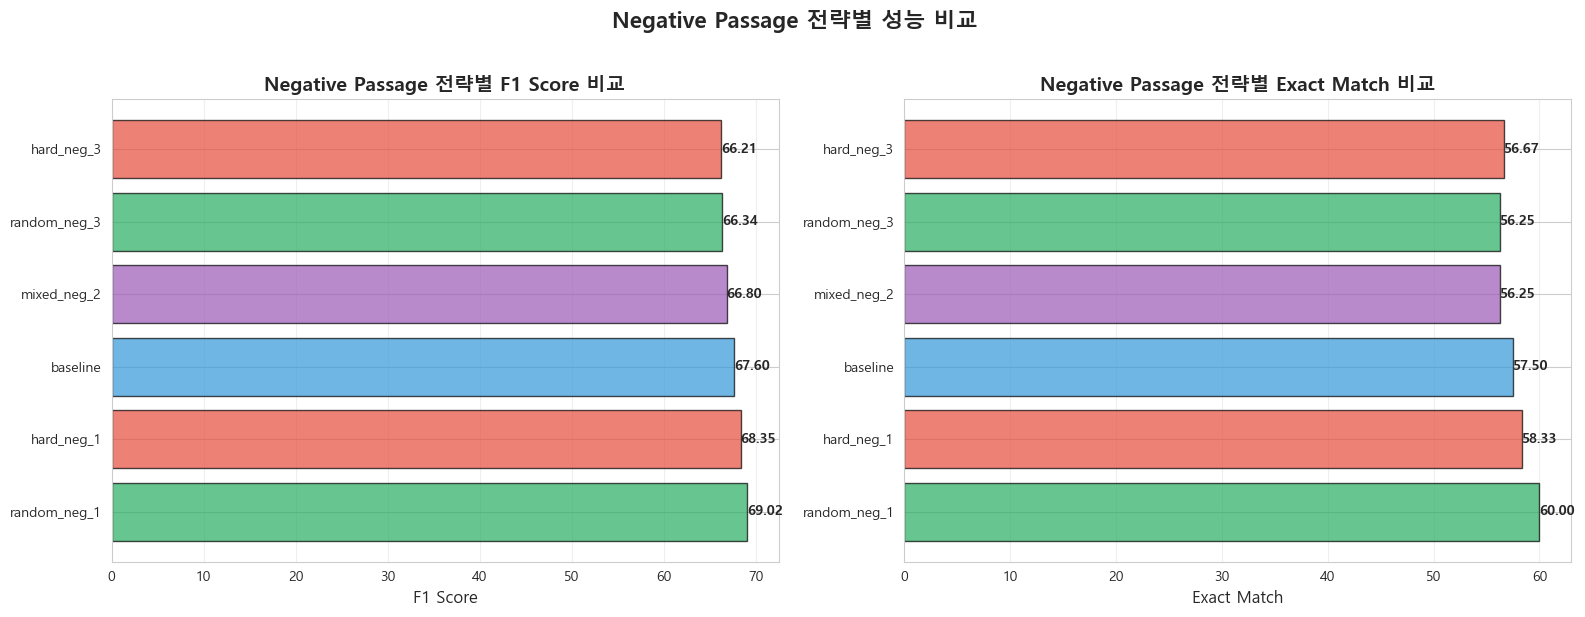

In [16]:
# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. F1 Score 비교
ax1 = axes[0]
colors = ['#3498db' if 'baseline' in name else '#27ae60' if 'random' in name else '#e74c3c' if 'hard' in name else '#9b59b6' 
          for name in results_df['experiment_name']]
bars1 = ax1.barh(results_df['experiment_name'], results_df['eval_f1'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_title('Negative Passage 전략별 F1 Score 비교', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 값 표시
for bar, val in zip(bars1, results_df['eval_f1']):
    ax1.text(val, bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
             ha='left', va='center', fontsize=10, fontweight='bold')

# 2. Exact Match 비교
ax2 = axes[1]
bars2 = ax2.barh(results_df['experiment_name'], results_df['eval_exact_match'], color=colors, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Exact Match', fontsize=12)
ax2.set_title('Negative Passage 전략별 Exact Match 비교', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 값 표시
for bar, val in zip(bars2, results_df['eval_exact_match']):
    ax2.text(val, bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Negative Passage 전략별 성능 비교', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


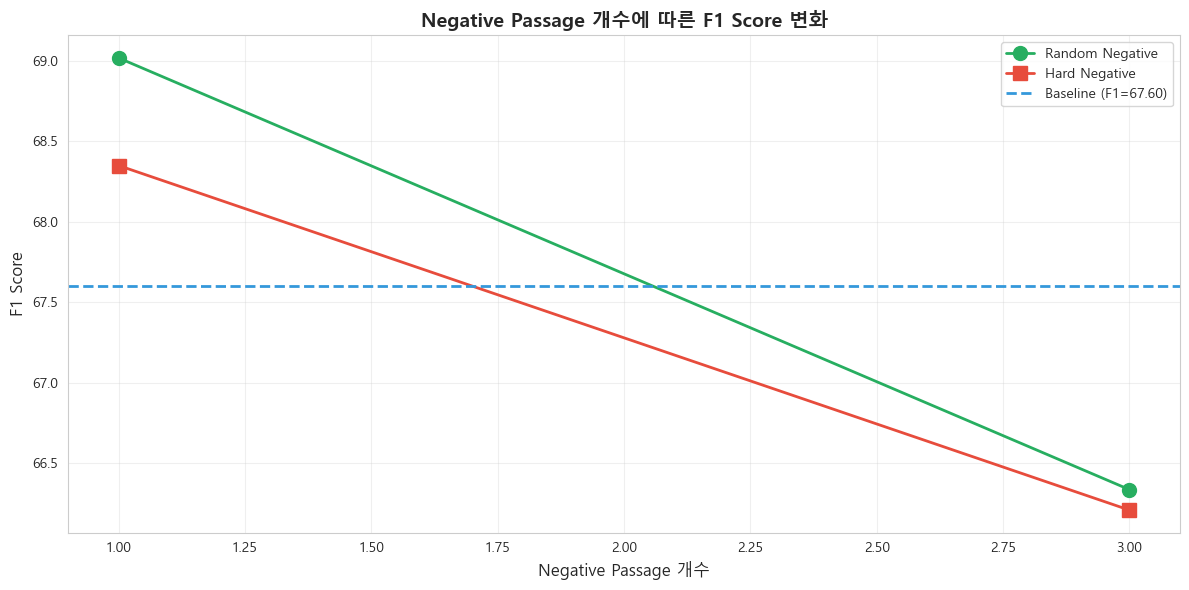

In [17]:
# Negative 개수에 따른 성능 변화 (전략별)
fig, ax = plt.subplots(figsize=(12, 6))

strategies = ['random', 'hard']
colors = {'random': '#27ae60', 'hard': '#e74c3c'}
markers = {'random': 'o', 'hard': 's'}

for strategy in strategies:
    strategy_data = results_df[results_df['strategy'] == strategy].sort_values('num_negatives')
    if len(strategy_data) > 0:
        ax.plot(strategy_data['num_negatives'], strategy_data['eval_f1'], 
                marker=markers[strategy], color=colors[strategy], linewidth=2, markersize=10,
                label=f'{strategy.capitalize()} Negative')

# Baseline 표시
baseline_f1 = results_df[results_df['strategy'] == 'none']['eval_f1'].values
if len(baseline_f1) > 0:
    ax.axhline(y=baseline_f1[0], color='#3498db', linestyle='--', linewidth=2, label=f'Baseline (F1={baseline_f1[0]:.2f})')

ax.set_xlabel('Negative Passage 개수', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Negative Passage 개수에 따른 F1 Score 변화', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5.9. 결론 및 권장사항


In [18]:
# 최종 분석 리포트
print("="*80)
print("Negative Passage 성능 실험 최종 리포트")
print("="*80)

# 최고 성능 전략
best_result = results_df.iloc[0]
baseline_result = results_df[results_df['strategy'] == 'none'].iloc[0] if len(results_df[results_df['strategy'] == 'none']) > 0 else None

print(f"\n[최고 성능 전략]")
print(f"  - 전략: {best_result['experiment_name']}")
print(f"  - F1 Score: {best_result['eval_f1']:.4f}")
print(f"  - Exact Match: {best_result['eval_exact_match']:.4f}")

if baseline_result is not None:
    f1_improvement = best_result['eval_f1'] - baseline_result['eval_f1']
    em_improvement = best_result['eval_exact_match'] - baseline_result['eval_exact_match']
    
    print(f"\n[Baseline 대비 개선]")
    print(f"  - F1 Score 개선: {f1_improvement:+.4f} ({f1_improvement/baseline_result['eval_f1']*100:+.2f}%)")
    print(f"  - Exact Match 개선: {em_improvement:+.4f} ({em_improvement/baseline_result['eval_exact_match']*100:+.2f}%)")

# 전략별 평균 성능
print(f"\n[전략별 평균 성능]")
for strategy in ['none', 'random', 'hard', 'mixed']:
    strategy_data = results_df[results_df['strategy'] == strategy]
    if len(strategy_data) > 0:
        avg_f1 = strategy_data['eval_f1'].mean()
        avg_em = strategy_data['eval_exact_match'].mean()
        print(f"  - {strategy.capitalize()}: F1={avg_f1:.4f}, EM={avg_em:.4f}")

# 권장사항
print(f"\n[권장사항]")
if best_result['strategy'] == 'hard':
    print("  → BM25 Hard Negative 전략이 가장 효과적입니다.")
    print("    Hard Negative를 통해 모델이 비슷하지만 정답이 없는 문서를 구별하는 능력이 향상됩니다.")
elif best_result['strategy'] == 'random':
    print("  → Random Negative 전략이 효과적입니다.")
    print("    다양한 Negative 샘플을 통해 모델의 일반화 능력이 향상됩니다.")
elif best_result['strategy'] == 'mixed':
    print("  → 혼합 전략 (Hard + Random)이 가장 효과적입니다.")
    print("    Hard Negative와 Random Negative의 장점을 결합하여 최적의 성능을 얻었습니다.")
else:
    print("  → Baseline이 가장 좋은 성능을 보입니다.")
    print("    현재 데이터셋에서는 Negative 샘플링이 효과가 없거나 오히려 성능을 저하시킬 수 있습니다.")

print("\n" + "="*80)


Negative Passage 성능 실험 최종 리포트

[최고 성능 전략]
  - 전략: random_neg_1
  - F1 Score: 69.0167
  - Exact Match: 60.0000

[Baseline 대비 개선]
  - F1 Score 개선: +1.4147 (+2.09%)
  - Exact Match 개선: +2.5000 (+4.35%)

[전략별 평균 성능]
  - None: F1=67.6020, EM=57.5000
  - Random: F1=67.6767, EM=58.1250
  - Hard: F1=67.2792, EM=57.5000
  - Mixed: F1=66.8027, EM=56.2500

[권장사항]
  → Random Negative 전략이 효과적입니다.
    다양한 Negative 샘플을 통해 모델의 일반화 능력이 향상됩니다.



In [19]:
# 결과 저장
report = {
    'experiment_config': {
        'model_name': experiment_config.model_name,
        'num_train_epochs': experiment_config.num_train_epochs,
        'learning_rate': experiment_config.learning_rate,
        'batch_size': experiment_config.per_device_train_batch_size
    },
    'results': all_results,
    'best_strategy': {
        'name': best_result['experiment_name'],
        'strategy': best_result['strategy'],
        'num_negatives': int(best_result['num_negatives']),
        'eval_f1': float(best_result['eval_f1']),
        'eval_exact_match': float(best_result['eval_exact_match'])
    }
}

if baseline_result is not None:
    report['baseline'] = {
        'eval_f1': float(baseline_result['eval_f1']),
        'eval_exact_match': float(baseline_result['eval_exact_match'])
    }
    report['improvement'] = {
        'f1_improvement': float(f1_improvement),
        'em_improvement': float(em_improvement)
    }

report_path = project_root / "notebooks" / "negative_passage" / "performance_experiment_report.json"
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"실험 리포트가 저장되었습니다: {report_path}")


실험 리포트가 저장되었습니다: D:\Repos\pro-nlp-mrc-nlp-01\notebooks\negative_passage\performance_experiment_report.json


## 5.10. 추가 분석 (선택사항)


In [20]:
# Negative 샘플 예시 확인
print("=== Negative 샘플 예시 ===")

# 예시 질문 하나 선택
example = train_datasets['train'][0]
question = example['question']
positive_context = example['context']
answer_text = example['answers']['text'][0]

print(f"\n질문: {question}")
print(f"정답: {answer_text}")
print(f"\nPositive Context (처음 200자):")
print(f"  {positive_context[:200]}...")

# Random Negative
random_negs = negative_sampler.sample_random_negatives(positive_context, answer_text, 2)
print(f"\nRandom Negative (2개):")
for i, neg in enumerate(random_negs, 1):
    print(f"  [{i}] {neg[:150]}...")

# Hard Negative
hard_negs = negative_sampler.sample_bm25_hard_negatives(question, positive_context, answer_text, 2)
print(f"\nHard Negative (2개):")
for i, neg in enumerate(hard_negs, 1):
    print(f"  [{i}] {neg[:150]}...")


=== Negative 샘플 예시 ===

질문: 대통령을 포함한 미국의 행정부 견제권을 갖는 국가 기관은?
정답: 하원

Positive Context (처음 200자):
  미국 상의원 또는 미국 상원(United States Senate)은 양원제인 미국 의회의 상원이다.\n\n미국 부통령이 상원의장이 된다. 각 주당 2명의 상원의원이 선출되어 100명의 상원의원으로 구성되어 있다. 임기는 6년이며, 2년마다 50개주 중 1/3씩 상원의원을 새로 선출하여 연방에 보낸다.\n\n미국 상원은 미국 하원과는 다르게 미국 대통령을 ...

Random Negative (2개):
  [1] 라 마르크가의 역사는 베스트팔렌 지역의 알테나 성에 거주하던 베르크가의 방계 가문의 자손인 아돌프 1세 폰 데어 마르크로부터 시작되었다. 13세기 초 아돌프는 오늘날 함우엔트롭 지역인 마르크 일대의 그의 가문의 영지에 그의 자리를 잡았다. 아돌프는 그의 아버지 프리드리...
  [2] "플랫 파일 데이터베이스"라는 용어에는 크게 좁은 의미와 넓은 의미로 나뉘어 쓰인다. 사람들은 좁은 의미로쓰기도 하는데 좁은 의미로 쓰는 것이 데이터베이스 이론에 알맞은 것이다. 그러나 대다수의 사람들은 넓은 의미로 많이 쓴다.

좁은 의미에서 “플랫 파일 데이터 베이...

Hard Negative (2개):
  [1] 이하의 국가들은 의회에서 행정부 수반을 선출한다는 점에서 내각제와 닮았다. 그리고 이들 국가들 중 상당수는 행정부 수반이 의회해산권을 갖고, 의회는 내각불신임권을 갖는데 이점 역시 내각제와 닮았다. 하지만 내각제와 달리 의회에서 선출되는 자는 행정부 수반의 지위 뿐만 ...
  [2] 재조사결정을 통지받은 이의신청인 등은 그에 따른 후속 처분의 통지를 받은 후에야 비로소 다음 단계의 쟁송절차에서 불복할 대상과 범위를 구체적으로 특정할 수 있게 되므로 재조사결정에 따른 심사청구기간이나 심판청구기간 또는 행정소송의 제소기간은 이의신청인 등이 후속 처분의...
